C:\Users\hayde\AppData\Local\Temp\ipykernel_24152\1246462703.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')  # Use 'tab10', 'tab20', or 'Set1' for distinct colors


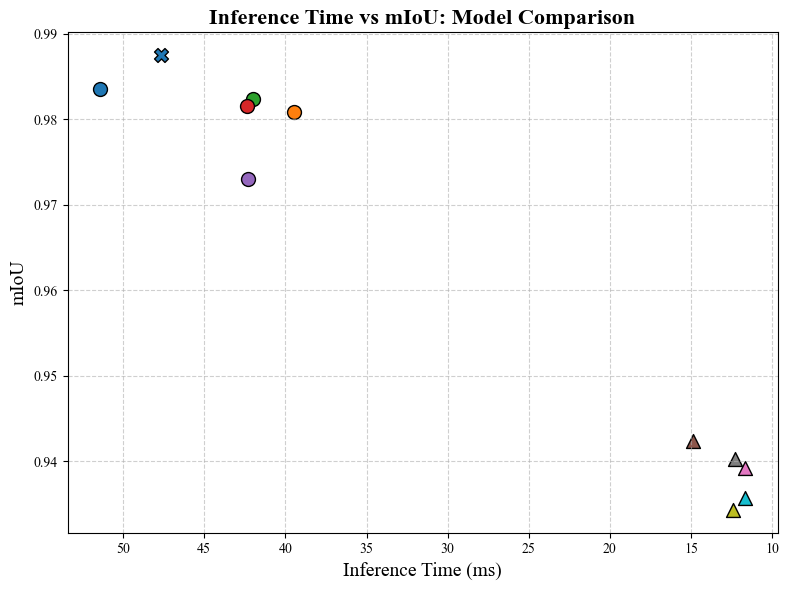

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.cm import get_cmap

# Set Times New Roman as the font
rcParams['font.family'] = 'Times New Roman'

# Data from your speed tests (replace these with your actual results)
models = ['SERTnetV1', 'SERTnetV2', 'SERTnetV3', 'SERTnetV4', 'SERTnetV5', 
          'SERTnetV1 AP', 'SERTnetV2 AP', 'SERTnetV3 AP', 'SERTnetV4 AP', 'SERTnetV5 AP', 'RITnet']
inference_times = np.array([51.43, 39.45, 42.02, 42.39, 42.28, 14.91, 11.67, 12.31, 12.43, 11.71, 47.66])  # Inference times in ms
accuracies = np.array([0.98360438, 0.98081104, 0.9824066, 0.981515, 0.97299985, 0.94236561, 0.93927223, 0.94029171, 0.93432966, 0.93570602, 0.98752444])  # Replace with actual accuracies
markers = ['o', 'o', 'o', 'o', 'o', '^', '^', '^', '^', '^', 'X']  # Add more markers if needed
# Use a qualitative colormap for distinct colors
cmap = get_cmap('tab10')  # Use 'tab10', 'tab20', or 'Set1' for distinct colors
colors = cmap(np.arange(len(models)) % cmap.N)  # Cycle through the colormap if there are more models than colors

# Create the scatter plot
plt.figure(figsize=(8, 6))

# Add labels for each point
for i, model in enumerate(models):
    plt.scatter(inference_times[i] , accuracies[i], color=colors[i], marker=markers[i], s=100, edgecolor='black', label=model)

# Formatting
plt.title('Inference Time vs mIoU: Model Comparison', fontsize=16, weight='bold')
plt.xlabel('Inference Time (ms)', fontsize=14)
plt.ylabel('mIoU', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_xaxis() # Invert x-axis for better readability
# Add a legend (key) for the models


# Save the plot as a high-resolution image for IEEE paper
plt.tight_layout()
plt.savefig('inference_time_vs_accuracy_with_distinct_colors.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

C:\Users\hayde\AppData\Local\Temp\ipykernel_24152\3884405567.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


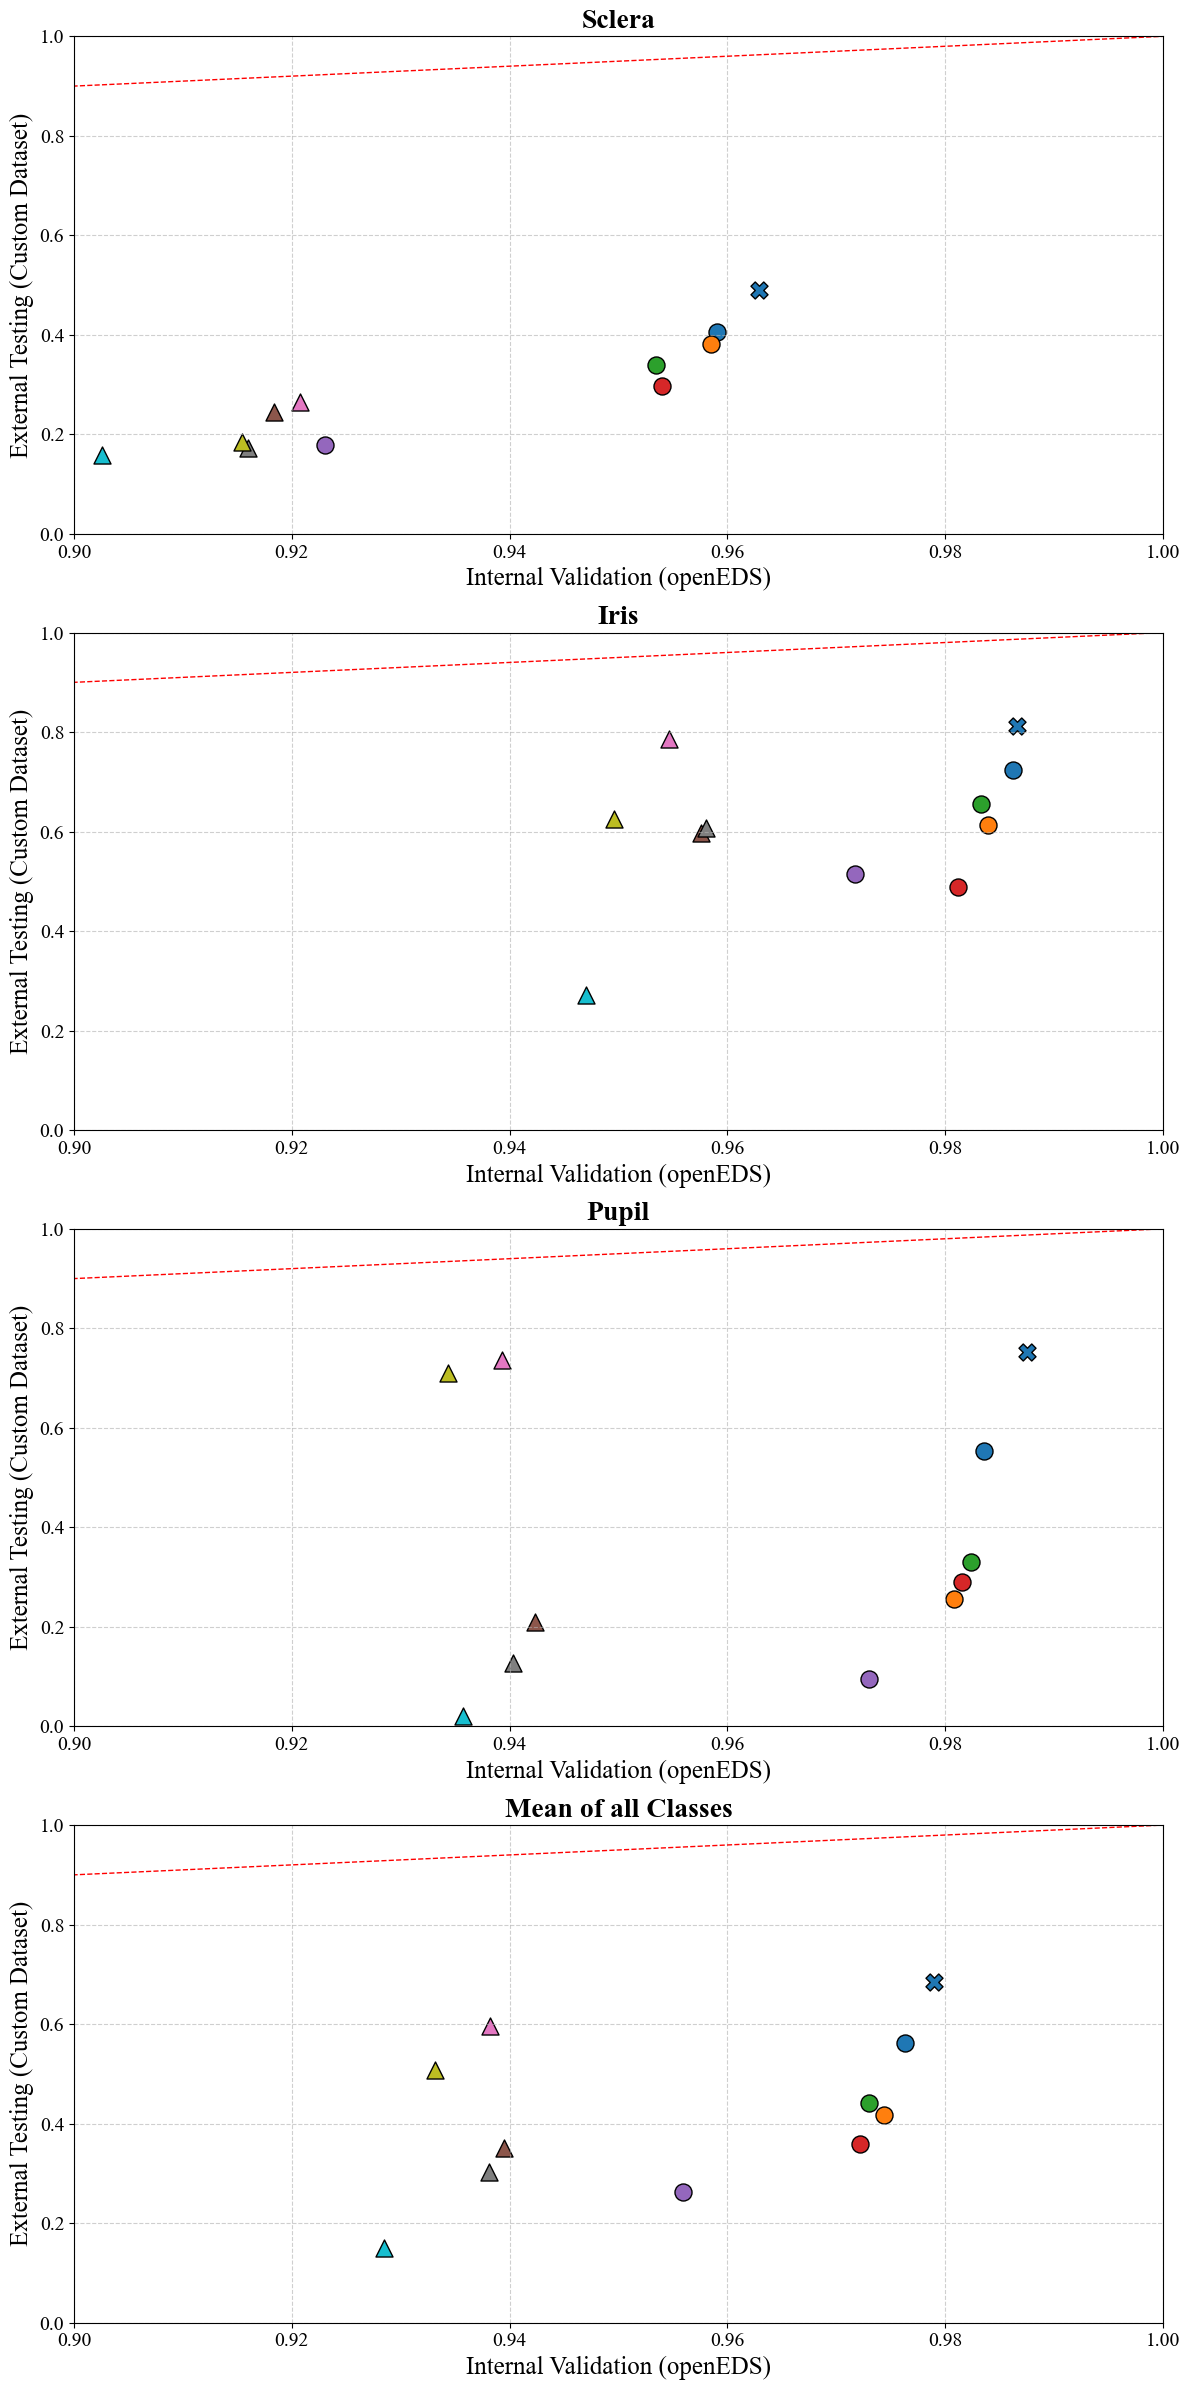

Internal overall:[0.97630224 0.97442519 0.97304194 0.97222701 0.95592276 0.93945397
 0.93823929 0.93810923 0.93313166 0.92844344 0.97900166]
Externaloverall: [0.56136667 0.41713333 0.4418     0.35863333 0.26266667 0.351
 0.59546667 0.30236667 0.50753333 0.14966667 0.68543333]


In [3]:
models = ['SERTnetV1', 'SERTnetV2', 'SERTnetV3', 'SERTnetV4', 'SERTnetV5', 
          'SERTnetV1 AP', 'SERTnetV2 AP', 'SERTnetV3 AP', 'SERTnetV4 AP', 'SERTnetV5 AP', 'RITnet']

arr_OPENEDS = np.array([
    [ 0.95902627, 0.98627608, 0.98360438],
    [0.95848446, 0.98398008, 0.98081104],
    [0.95341301, 0.98330622, 0.9824066 ],
    [0.95397246, 0.98119356, 0.981515  ],
    [0.92305152, 0.9717169,  0.97299985],
    [0.91841016, 0.95758615, 0.94236561],
    [0.92075417, 0.95469148, 0.93927223],
    [0.91597958, 0.95805639, 0.94029171],
    [0.91546214, 0.94960318, 0.93432966],
    [0.90261437, 0.94700992, 0.93570602],
    [0.96289887, 0.98658167, 0.98752444]]
)
arr_EXTERNAL = np.array([
    [0.4055, 0.7248, 0.5538],
    [0.3810, 0.6134, 0.2570],
    [0.3403, 0.6556, 0.3295],
    [0.2965, 0.4892, 0.2902],
    [0.1792, 0.5145, 0.0943],
    [0.2456, 0.5972, 0.2102],
    [0.2649, 0.7855, 0.7360],
    [0.1717, 0.6072, 0.1282],
    [0.1855, 0.6261, 0.7110],
    [0.1577, 0.2710, 0.0203],
    [.4911, 0.8124, 0.7528],
]
)

internal_overall = arr_OPENEDS.mean(axis=1)
external_overall = arr_EXTERNAL.mean(axis=1)

markers = ['o', 'o', 'o', 'o', 'o', '^', '^', '^', '^', '^', 'X']
cmap = get_cmap('tab10')
colors = cmap(np.arange(len(models)) % cmap.N)

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 24))  # Increased figure size
categories = ['Sclera', 'Iris', 'Pupil', 'Mean of all Classes']
data_pairs = [
    (arr_OPENEDS[:, 0], arr_EXTERNAL[:, 0]),  # Pupil
    (arr_OPENEDS[:, 1], arr_EXTERNAL[:, 1]),  # Iris
    (arr_OPENEDS[:, 2], arr_EXTERNAL[:, 2]),  # Sclera
    (internal_overall, external_overall)      # Overall
]

# Plot each category
for ax, (internal, external), category in zip(axes.flatten(), data_pairs, categories):
    for i, model in enumerate(models):
        ax.scatter(internal[i], external[i], color=colors[i], marker=markers[i], s=150, edgecolor='black', label=model if category == 'Pupil' else None)  # Increased marker size
    ax.set_title(f'{category}', fontsize=20, weight='bold')  # Larger title
    ax.set_xlabel('Internal Validation (openEDS)', fontsize=18)  # Larger x-axis label
    ax.set_ylabel('External Testing (Custom Dataset)', fontsize=18)  # Larger y-axis label
    ax.tick_params(axis='both', which='major', labelsize=14)  # Larger tick labels
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)  # Diagonal line for reference
    ax.set_xlim(0.9, 1)
    ax.set_ylim(0, 1)

# handles = [
#     plt.Line2D([0], [0], marker=markers[i], color='w', markerfacecolor=colors[i], markersize=10, label=models[i])
#     for i in range(len(models))
# ]

# plt.legend(
#     handles,
#     models,
#     loc='upper center',  # Position the legend above the plot
#     bbox_to_anchor=(0.5, -0.15),  # Center the legend horizontally and move it down
#     fontsize=16,  # Adjust legend text size
#     title='Models',
#     title_fontsize=18,  # Adjust legend title size
#     frameon=False,  # Remove legend border
#     ncol=4  # Display the legend in 3 columns
# )
# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('performance_comparison_with_larger_text.png', dpi=300, bbox_inches='tight')  # Save as high-resolution image
plt.show()

print(f"Internal overall:{internal_overall}")
print(f"Externaloverall: {external_overall}")